In [1]:
!pip install tensorflow pandas numpy
!rm -rf /content/sample_data/x_train_unzipped /content/sample_data/x_test_unzipped
!mkdir -p /content/sample_data/x_train_unzipped /content/sample_data/x_test_unzipped
!unzip -q -j /content/sample_data/x_train.zip -d /content/sample_data/x_train_unzipped
!unzip -q -j /content/sample_data/x_test.zip -d /content/sample_data/x_test_unzipped

import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

BASE_DIR = '/content/sample_data'
Y_TRAIN_CSV = os.path.join(BASE_DIR, 'y_train_v2.csv')
Y_TEST_EX_CSV = os.path.join(BASE_DIR, 'y_test_submission_example_v2.csv')
TRAIN_EXTRACT_DIR = os.path.join(BASE_DIR, 'x_train_unzipped')
TEST_EXTRACT_DIR = os.path.join(BASE_DIR, 'x_test_unzipped')

df_train = pd.read_csv(Y_TRAIN_CSV)
df_train['label'] = df_train['target'].astype(str)
df_train['filename'] = 'img_' + (df_train['id'] + 1).astype(str) + '.png'

IMG_SIZE = (96, 96)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    width_shift_range=0.05,
    height_shift_range=0.05
)

valid_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train, directory=TRAIN_EXTRACT_DIR, x_col="filename", y_col="label",
    subset="training", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical"
)

valid_generator = valid_datagen.flow_from_dataframe(
    dataframe=df_train, directory=TRAIN_EXTRACT_DIR, x_col="filename", y_col="label",
    subset="validation", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False
)

model = Sequential([
    tf.keras.layers.InputLayer(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    Conv2D(32, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)

print("\nTraining started: Sniper Mode...")
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=60,
    callbacks=[early_stop, reduce_lr]
)

test_files = [f for f in os.listdir(TEST_EXTRACT_DIR) if f.lower().endswith('.png')]

def extract_number(filename):
    num_str = filename.replace('img_', '').replace('.png', '')
    return int(num_str) if num_str.isdigit() else 0

test_files.sort(key=extract_number)
df_test = pd.DataFrame({'filename': test_files})

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_dataframe(
    dataframe=df_test, directory=TEST_EXTRACT_DIR, x_col="filename", y_col=None,
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode=None, shuffle=False
)

print("\nPrediction in progress...")
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

labels = (train_generator.class_indices)
labels = {v: k for k, v in labels.items()}
final_predictions = [labels[k] for k in predicted_classes]

submission_df = pd.read_csv(Y_TEST_EX_CSV)
submission_df['target'] = final_predictions
submission_csv_path = os.path.join(BASE_DIR, 'submission_finale_SNIPER.csv')
submission_df.to_csv(submission_csv_path, index=False)

print(f"\nFile ready for Kaggle: {submission_csv_path}")

Found 7382 validated image filenames belonging to 4 classes.
Found 1845 validated image filenames belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



Training started: Sniper Mode...
Epoch 1/60
231/231 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step - accuracy: 0.6806 - loss: 0.8129 - val_accuracy: 0.4168 - val_loss: 1.9008 - learning_rate: 0.0010
Epoch 2/60
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.7830 - loss: 0.5230 - val_accuracy: 0.5431 - val_loss: 1.0565 - learning_rate: 0.0010
Epoch 3/60
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - accuracy: 0.8192 - loss: 0.4526 - val_accuracy: 0.8309 - val_loss: 0.4563 - learning_rate: 0.0010
Epoch 4/60
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - accuracy: 0.8477 - loss: 0.3856 - val_accuracy: 0.8650 - val_loss: 0.3400 - learning_rate: 0.0010
Epoch 5/60
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.8551 - loss: 0.3524 - val_accuracy: 0.8260 - val_loss: 0.5421 - learning_rate: 0.0010
Epoch 6/60
231/231 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.8712 - loss: 0.3183 - val_accuracy: 0.7572 - val_loss: 0.6110 - learning_rate: 0.0010
Epoch 7/60
231/231 ━━━━━━━━━━━━━━━━━━━━ 2

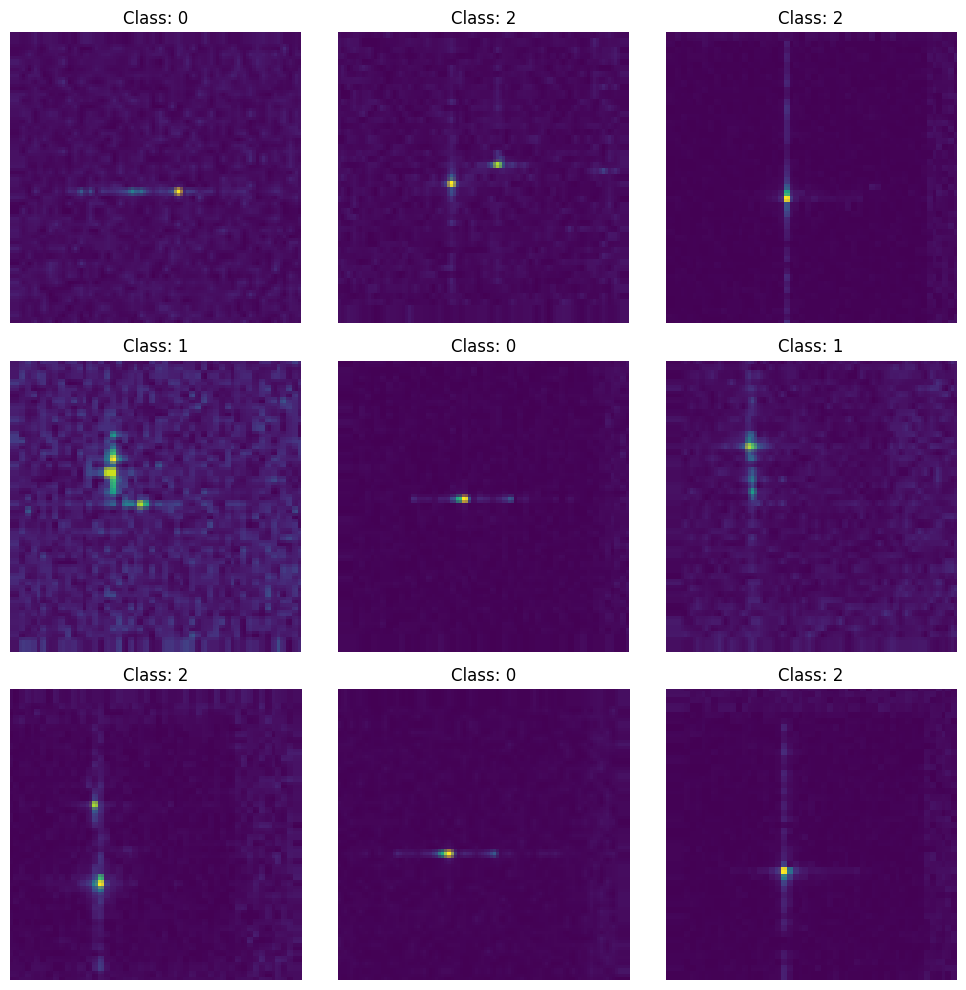

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Récupérer un lot d'images
x, y = next(train_generator)
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x[i])
    plt.title(f"Class: {np.argmax(y[i])}")
    plt.axis('off')
plt.tight_layout()
plt.savefig('real_snapshots.png', dpi=300)
plt.show()

58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step


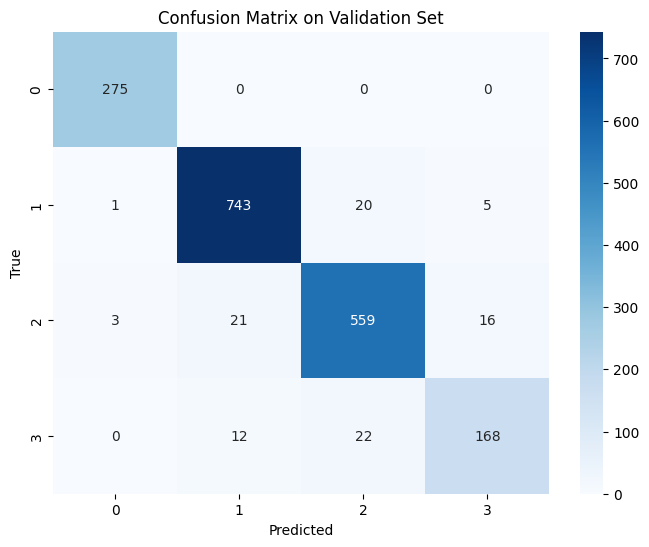

In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Prédiction sur le set de validation
val_preds = model.predict(valid_generator)
val_labels = np.argmax(val_preds, axis=1)
true_labels = valid_generator.classes

cm = confusion_matrix(true_labels, val_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1', '2', '3'],
            yticklabels=['0', '1', '2', '3'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix on Validation Set')
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

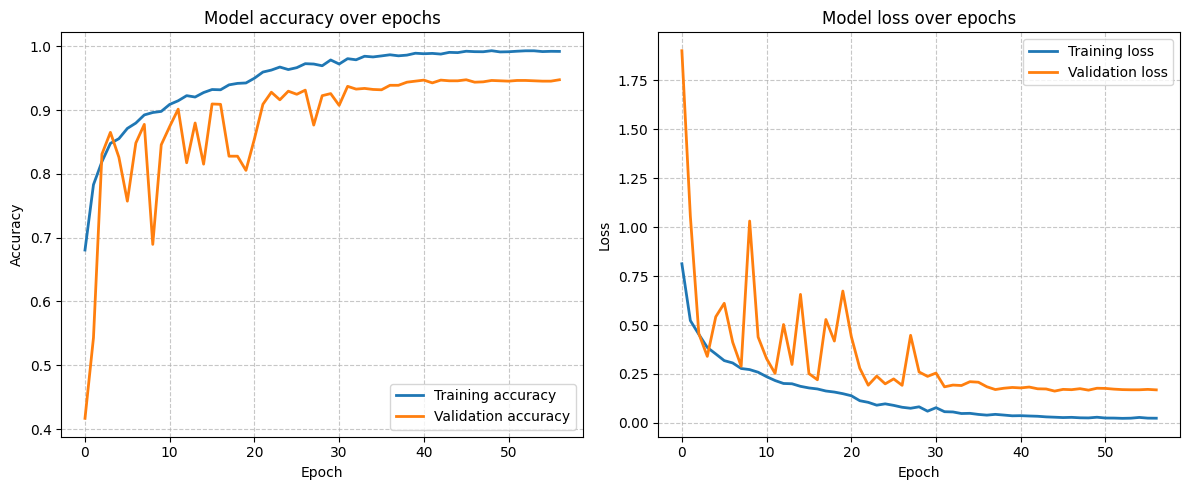


L'image 'training_curves.png' est sauvegardée dans le dossier racine de Colab.


In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training accuracy', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color='#ff7f0e', linewidth=2)
plt.title('Model accuracy over epochs', fontsize=12)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training loss', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation loss', color='#ff7f0e', linewidth=2)
plt.title('Model loss over epochs', fontsize=12)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nL'image 'training_curves.png' est sauvegardée dans le dossier racine de Colab.")